In [1]:
import numpy as np
import pandas as pd
import re

In [2]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('BPL_cleaned_l3_v1.csv')

In [4]:
df.head(1)
# # focus is on ->Area, additional room,property age,  furnish, features
df.drop(columns=['description'],inplace=True)

# 1.Area

In [5]:
df.head()

,pname,society,colony,property_type,price_outer,price_per_sqft,possesion,Area,Total Floors,Facing,Property Age,furnishing,features,Overlooking,bedrooms,bathrooms,balconies,additional_room,area
0,"7 Bedroom House for sale in Jhagariya Khurd, Bhopal",sage suncity,bhopal,House,105.0,3750,Ready To Move,Built Up area: 2800\n(260.13 sq.m.) \nsq.ft.,1.0,NaN,NaN,NaN,NaN,NaN,7,5,0,Not Available,2800.00
1,"3 BHK Flat in Kolar Road, Bhopal",danish hills view,kolar road,Flat,85.0,6508,Ready To Move,Carpet area: 1306\n(121.33 sq.m.) \nsq.ft.,2.0,North,0 to 1 Year Old,NaN,"['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']",Park/Garden,3,3,1,pooja room with view floor plan,1306.08
2,"2 BHK Flat in Katara Hills, Bhopal",narmada prem kesar,katara hills,Flat,25.0,2173,Ready To Move,Super Built up area 1150\n(106.84 sq.m.)\nCarpet area: 850 sq.ft. (78.97 sq.m.) \nsq.ft.,3.0,West,1 to 5 Year Old View Construction Status,NaN,"['Feng Shui / Vaastu Compliant', 'Lift(s)', 'Maintenance Staff', 'Water Storage']","Park/Garden,Main Road",2,2,3,Not Available,1150.48
3,"8 Bedroom House for sale in Gurunanak Pura, Bhopal",gurunanak pura independent house,aishbagh,House,65.0,5909,Ready To Move,Plot area 1100\n(102.19 sq.m.)\nBuilt Up area: 2400 sq.ft. (222.97 sq.m.)\nCarpet area: 2200 sq.ft. (204.39 sq.m.) \nsq.ft.,2.0,West,10+ Year Old,"['1 Water Purifier', '12 Fan', '1 Geyser', '22 Light', '2 AC', '1 Chimney', '8 Curtains', '1 Modular Kitchen', '1 TV', '3 Wardrobe', '1 Sofa', 'No Bed', 'No Dining Table', 'No Exhaust Fan', 'No Microwave', 'No Fridge', 'No Stove', 'No Washing Machine']","['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Water Storage', 'Waste Disposal']",Main Road,8,5,1,pooja room,1100.02
4,"6 Bedroom House for sale in Chuna Bhatti, Bhopal",chuna bhatti,chuna bhatti,House,650.0,16250,Ready To Move,Plot area 4000\n(371.61 sq.m.) \nsq.ft.,3.0,NaN,1 to 5 Year Old,"['1 Water Purifier', '1 Fan', '1 Exhaust Fan', '1 Dining Table', '1 Stove', '1 Light', '1 Modular Kitchen', '1 Chimney', '1 AC', '1 Curtains', '1 Sofa', '1 Microwave', 'No Bed', 'No Geyser', 'No Fridge', 'No TV', 'No Wardrobe', 'No Washing Machine']",NaN,NaN,6,6,2,"pooja room,study room,servant room,store room",4000.00


In [6]:
df['Area'] = df['Area'].str.replace('\n','').str.strip()

In [7]:
df.sample(5)[['price_outer','area','Area']]

,price_outer,area,Area
1446,28.0,790.07,Carpet area: 790(73.39 sq.m.) sq.ft.
1468,55.1,1276.05,Plot area 1400(130.06 sq.m.) sq.ft.
1199,145.0,1200.03,Plot area 1200(111.48 sq.m.) sq.ft.
1092,120.0,2000.00,Built Up area: 2000(185.81 sq.m.) sq.ft.
243,32.0,1074.55,Super Built up area 940(87.33 sq.m.)Built Up area: 850 sq.ft. (78.97 sq.m.) sq.ft.


In [8]:
import re
import pandas as pd

SQM_TO_SQFT = 10.7639

def extract_area_from_sqm(text, area_type):
    if pd.isna(text):
        return None

    text = str(text).lower()

    if area_type == 'super built':
        pattern = r'super\s*built\s*up.*?(\d+\.?\d*)\s*(?:sq\.?\s*m|sqm)'

    elif area_type == 'built up':
        # built up but NOT super built up
        pattern = r'(?<!super\s)built\s*up.*?(\d+\.?\d*)\s*(?:sq\.?\s*m|sqm)'

    elif area_type == 'carpet':
        pattern = r'carpet\s*area.*?(\d+\.?\d*)\s*(?:sq\.?\s*m|sqm)'

    elif area_type == 'plot area':
        pattern = r'plot\s*area.*?(\d+\.?\d*)\s*(?:sq\.?\s*m|sqm)'

    else:
        return None

    match = re.search(pattern, text, flags=re.IGNORECASE | re.DOTALL)
    if match:
        return round(float(match.group(1)) * SQM_TO_SQFT,0)

    return None


In [9]:
df['super_built_up_area'] = df['Area'].apply(
    lambda x: extract_area_from_sqm(x, 'super built')
)

df['built_up_area'] = df['Area'].apply(
    lambda x: extract_area_from_sqm(x, 'built up')
)

df['carpet_area'] = df['Area'].apply(
    lambda x: extract_area_from_sqm(x, 'carpet')
)

df['plot_area'] = df['Area'].apply(
    lambda x: extract_area_from_sqm(x, 'plot area')
)


In [10]:
df[['price_outer','area','super_built_up_area','built_up_area','carpet_area','plot_area']].sample(20)

,price_outer,area,super_built_up_area,built_up_area,carpet_area,plot_area
899,24.0,890.21,890.0,NaN,NaN,NaN
596,25.0,901.23,NaN,900.0,600.0,NaN
858,42.0,1577.17,NaN,NaN,1577.0,NaN
1018,35.0,650.07,NaN,NaN,650.0,NaN
931,375.0,2400.00,NaN,3050.0,2800.0,2400.0
670,130.0,2300.07,NaN,2700.0,2300.0,1500.0
568,95.0,900.05,NaN,NaN,900.0,NaN
914,77.0,1000.00,NaN,NaN,NaN,1000.0
625,30.0,730.10,730.0,540.0,500.0,NaN
1041,48.0,1515.15,NaN,NaN,1515.0,NaN


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1580 entries, 0 to 1579
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   pname                1580 non-null   object 
 1   society              1576 non-null   object 
 2   colony               1580 non-null   object 
 3   property_type        1580 non-null   object 
 4   price_outer          1580 non-null   float64
 5   price_per_sqft       1580 non-null   int64  
 6   possesion            1580 non-null   object 
 7   Area                 1580 non-null   object 
 8   Total Floors         1546 non-null   float64
 9   Facing               876 non-null    object 
 10  Property Age         1443 non-null   object 
 11  furnishing           673 non-null    object 
 12  features             1015 non-null   object 
 13  Overlooking          792 non-null    object 
 14  bedrooms             1580 non-null   int64  
 15  bathrooms            1580 non-null   i

In [12]:
tolerance = 1

mask = ~(
    ((df['area'] - df['super_built_up_area']).abs() <= tolerance) |
    ((df['area'] - df['built_up_area']).abs() <= tolerance) |
    ((df['area'] - df['carpet_area']).abs() <= tolerance) |
    ((df['area'] - df['plot_area']).abs() <= tolerance)
)

mismatch_rows = df[mask]

mismatch_rows.shape

(76, 23)

In [13]:
mismatch_rows[['area','Area','super_built_up_area','built_up_area','carpet_area','plot_area']]

,area,Area,super_built_up_area,built_up_area,carpet_area,plot_area
15,812.61,Plot area 650(60.39 sq.m.) sq.ft.,NaN,NaN,NaN,650.0
16,1657.86,Super Built up area 1802(167.41 sq.m.) sq.ft.,1802.0,NaN,NaN,NaN
30,869.40,Super Built up area 850(78.97 sq.m.) sq.ft.,850.0,NaN,NaN,NaN
43,17955.80,Carpet area: 1668 sq.m.,NaN,NaN,17954.0,NaN
50,4734.85,Built Up area: 4600(427.35 sq.m.)Carpet area: 2400 sq.ft. (222.97 sq.m.) sq.ft.,NaN,4600.0,2400.0,NaN
56,1669.32,Plot area 1550(144 sq.m.)Built Up area: 2400 sq.ft. (222.97 sq.m.)Carpet area: 2250 sq.ft. (209.03 sq.m.) sq.ft.,NaN,2400.0,2250.0,1550.0
73,912.83,Super Built up area 890(82.68 sq.m.) sq.ft.,890.0,NaN,NaN,NaN
82,3666.67,Plot area 3200(297.29 sq.m.) sq.ft.,NaN,NaN,NaN,3200.0
116,626.14,Plot area 600(55.74 sq.m.)Built Up area: 1100 sq.ft. (102.19 sq.m.) sq.ft.,NaN,1100.0,NaN,600.0
128,1147.89,Plot area 1100(102.19 sq.m.) sq.ft.,NaN,NaN,NaN,1100.0


In [14]:
df.isnull().sum()

pname                     0
society                   4
colony                    0
property_type             0
price_outer               0
price_per_sqft            0
possesion                 0
Area                      0
Total Floors             34
Facing                  704
Property Age            137
furnishing              907
features                565
Overlooking             788
bedrooms                  0
bathrooms                 0
balconies                 0
additional_room           0
area                      0
super_built_up_area    1227
built_up_area          1130
carpet_area             925
plot_area               838
dtype: int64

In [15]:
df.isnull().sum()/df.shape[0]

pname                  0.000000
society                0.002532
colony                 0.000000
property_type          0.000000
price_outer            0.000000
price_per_sqft         0.000000
possesion              0.000000
Area                   0.000000
Total Floors           0.021519
Facing                 0.445570
Property Age           0.086709
furnishing             0.574051
features               0.357595
Overlooking            0.498734
bedrooms               0.000000
bathrooms              0.000000
balconies              0.000000
additional_room        0.000000
area                   0.000000
super_built_up_area    0.776582
built_up_area          0.715190
carpet_area            0.585443
plot_area              0.530380
dtype: float64

In [16]:
df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))][['price_outer']]

,price_outer
111,31.5
202,300.0
206,100.0
225,200.0
261,140.0
302,35.0
305,31.0
311,57.0
419,23.9
429,15.0


In [17]:
# df['effective_area_sqft'] = None

# df.loc[df['property_type'] == 'House', 'effective_area_sqft'] = df['plot_area']
# df.loc[df['property_type'] == 'Flat',  'effective_area_sqft'] = df['super_built_up_area']


In [18]:
df.isnull().sum()

pname                     0
society                   4
colony                    0
property_type             0
price_outer               0
price_per_sqft            0
possesion                 0
Area                      0
Total Floors             34
Facing                  704
Property Age            137
furnishing              907
features                565
Overlooking             788
bedrooms                  0
bathrooms                 0
balconies                 0
additional_room           0
area                      0
super_built_up_area    1227
built_up_area          1130
carpet_area             925
plot_area               838
dtype: int64

In [19]:
# df[df['effective_area_sqft'].isnull()][['area','Area','super_built_up_area','built_up_area','carpet_area','plot_area','effective_area_sqft']]

In [20]:
# df.drop(columns=['super_built_up_area','plot_area'],inplace=True)

# 2.additionalRoom

In [21]:
df['additional_room'] = df['additional_room'].str.strip().str.lower()

In [22]:
df['additional_room'].value_counts()

additional_room
not available                                                     1148
pooja room                                                          75
others                                                              73
pooja room,study room                                               31
view floor plan                                                     30
servant room                                                        24
study room                                                          15
pooja room,study room,servant room,others                           14
pooja room,others                                                   13
pooja room,study room,servant room,store room                       12
store room                                                          10
pooja room,servant room                                              9
study room,others                                                    9
study room,pooja room,others                                 

In [23]:
# additional room
# List of new columns to be created
new_cols = ['study room', 'servant room', 'store room', 'pooja room', 'others','view floor plan']

# Populate the new columns based on the "additionalRoom" column
for col in new_cols:
    df[col] = df['additional_room'].str.contains(col).astype(int)

In [24]:
df.sample(20)[['additional_room','study room', 'servant room', 'store room', 'pooja room', 'others','view floor plan']]

,additional_room,study room,servant room,store room,pooja room,others,view floor plan
722,not available,0,0,0,0,0,0
813,pooja room,0,0,0,1,0,0
1206,not available,0,0,0,0,0,0
276,not available,0,0,0,0,0,0
1059,not available,0,0,0,0,0,0
36,"study room,others,servant room",1,1,0,0,1,0
1497,not available,0,0,0,0,0,0
1217,not available,0,0,0,0,0,0
911,"pooja room,study room",1,0,0,1,0,0
55,not available,0,0,0,0,0,0


# 3.agePossession

In [25]:
df['Property Age'].value_counts()

Property Age
5 to 10 Year Old                                441
1 to 5 Year Old                                 390
10+ Year Old                                    355
0 to 1 Year Old                                 116
1 to 5 Year Old    View Construction Status      70
5 to 10 Year Old    View Construction Status     34
0 to 1 Year Old    View Construction Status      18
Under Construction                               14
10+ Year Old    View Construction Status          5
Name: count, dtype: int64

In [26]:
def categorize_property_age(value):
    if pd.isna(value):
        return None

    value = value.lower()

    if 'under construction' in value:
        return 'Under Construction'

    elif '0 to 1' in value or '1 to 5' in value:
        return 'New Property'

    elif '5 to 10' in value:
        return 'Moderate Property'

    elif '10+' in value:
        return 'Old Property'

    else:
        return 'Unknown'


In [27]:
df['Property Age'] = df['Property Age'].apply(categorize_property_age)


In [28]:
df['Property Age'].value_counts()

Property Age
New Property          594
Moderate Property     475
Old Property          360
Under Construction     14
Name: count, dtype: int64

In [29]:
# under construction
# 1 - 5 = new property 
# 5 - 10 = moderate property
# 10 + = old property

# 4.furnishDetails

In [30]:
df.head(1)

,pname,society,colony,property_type,price_outer,price_per_sqft,possesion,Area,Total Floors,Facing,Property Age,furnishing,features,Overlooking,bedrooms,bathrooms,balconies,additional_room,area,super_built_up_area,built_up_area,carpet_area,plot_area,study room,servant room,store room,pooja room,others,view floor plan
0,"7 Bedroom House for sale in Jhagariya Khurd, Bhopal",sage suncity,bhopal,House,105.0,3750,Ready To Move,Built Up area: 2800(260.13 sq.m.) sq.ft.,1.0,NaN,None,NaN,NaN,NaN,7,5,0,not available,2800.0,NaN,2800.0,NaN,NaN,0,0,0,0,0,0


In [31]:
df.sample(5)[['furnishing','features']]

,furnishing,features
1052,NaN,"['Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']"
380,"['5 Fan', '1 Exhaust Fan', '5 Light', '1 Modular Kitchen', '1 Chimney', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Swimming Pool', 'Maintenance Staff', 'Security Personnel', 'Fitness Centre / GYM', 'Club house / Community Center', 'Rain Water Harvesting']"
531,NaN,"['Maintenance Staff', 'Water Storage']"
296,"['2 Wardrobe', '6 Fan', '1 Exhaust Fan', '1 Geyser', '8 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'No open drainage around', 'Piped-gas', 'Visitor Parking', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal']"
1373,NaN,NaN


In [32]:
# extract all unique furnishing
all_furnishing = []
for detail in df['furnishing'].dropna():
    furnishing = detail.replace('[',"").replace(']',"").replace("'","").lower().split(',')
    all_furnishing.extend(furnishing)
unique_furnishings = list(set(all_furnishing))
print(unique_furnishings)

[' 5 bed', '6 bed', ' 7 light', ' 9 wardrobe', ' 6 light', ' 9 geyser', ' 2 geyser', ' 1 sofa', '2 fan', ' no water purifier', ' 3 fan', ' no chimney', ' 2 fan', ' 30 light', ' 12 fan', ' 10 fan', '10 fan', ' 16 light', ' 10 bed', '9 fan', ' 5 wardrobe', ' no wardrobe', ' 1 wardrobe', ' 3 tv', '5 wardrobe', ' 2 bed', ' 36 light', ' no sofa', ' no curtains', ' 1 bed', ' 5 ac', ' 1 geyser', ' 12 light', ' 11 light', '8 wardrobe', ' 21 light', ' 6 fan', ' 13 light', '1 modular kitchen', ' 10 light', ' no modular kitchen', ' 4 wardrobe', '3 bed', '3 fan', ' 5 geyser', ' 4 geyser', ' 27 light', ' 10 ac', ' 1 fan', ' 40 light', ' 8 wardrobe', '20 fan', ' no tv', ' 2 ac', ' 4 light', ' no stove', ' 14 light', '3 light', '1 tv', '2 wardrobe', ' 10 wardrobe', '1 chimney', ' 6 wardrobe', ' 12 curtains', ' no dining table', ' 1 chimney', ' 1 microwave', ' 1 light', ' 9 fan', ' 15 light', ' 8 fan', ' 22 light', '8 fan', '20 light', ' 7 wardrobe', '2 bed', ' 4 fan', ' 17 light', '3 wardrobe', ' 5 f

In [33]:
# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [re.sub(r'no |\d+', '', furnishing).strip() for furnishing in unique_furnishings]
columns_to_include = list(set(columns_to_include))
columns_to_include = [furnishing for furnishing in columns_to_include if furnishing]
columns_to_include

['stove',
 'ac',
 'curtains',
 'dining table',
 'exhaust fan',
 'light',
 'washing machine',
 'tv',
 'wardrobe',
 'water purifier',
 'geyser',
 'fridge',
 'modular kitchen',
 'microwave',
 'bed',
 'sofa',
 'fan',
 'chimney']

In [34]:
# Define a function to extract the count of a furnishing from the furnishDetails
# def get_furnishing_count(details, furnishing):
#     if isinstance(details, str):
#         if f"No {furnishing}" in details:
#             return 0
#         pattern = re.compile(rf'(\d+)\s*{furnishing}')
#         match = pattern.search(details)
#         if match:
#             return int(match.group(1))
#         elif furnishing in details:
#             return 1
#     return 0

import re

def get_furnishing_count(details, furnishing):
    if not isinstance(details, str):
        return 0

    furnishing = furnishing.lower()

    # convert string list → python list
    items = re.findall(r"'([^']+)'", details.lower())

    total = 0

    for item in items:
        # skip "no <item>"
        if item.startswith('no ') and furnishing in item:
            continue

        # exact furnishing match
        if furnishing in item:
            # extract number if present
            num = re.search(r'(\d+)', item)
            if num:
                total += int(num.group(1))
            else:
                total += 1

    return total


In [35]:
# Create new columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishing'].apply(lambda x: get_furnishing_count(x, furnishing))

# Create the new dataframe with the required columns
furnishings_df = df[['furnishing'] + columns_to_include]

In [36]:
furnishings_df

,furnishing,stove,ac,curtains,dining table,exhaust fan,light,washing machine,tv,wardrobe,water purifier,geyser,fridge,modular kitchen,microwave,bed,sofa,fan,chimney
0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,"['1 Water Purifier', '12 Fan', '1 Geyser', '22 Light', '2 AC', '1 Chimney', '8 Curtains', '1 Modular Kitchen', '1 TV', '3 Wardrobe', '1 Sofa', 'No Bed', 'No Dining Table', 'No Exhaust Fan', 'No Microwave', 'No Fridge', 'No Stove', 'No Washing Machine']",0,2,8,0,0,22,0,1,3,1,1,0,1,0,0,1,12,1
4,"['1 Water Purifier', '1 Fan', '1 Exhaust Fan', '1 Dining Table', '1 Stove', '1 Light', '1 Modular Kitchen', '1 Chimney', '1 AC', '1 Curtains', '1 Sofa', '1 Microwave', 'No Bed', 'No Geyser', 'No Fridge', 'No TV', 'No Wardrobe', 'No Washing Machine']",1,1,1,1,1,1,0,0,0,1,0,0,1,1,0,1,2,1
5,"['8 Fan', '10 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",0,0,0,0,0,10,0,0,0,0,0,0,0,0,0,0,8,0
6,"['1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
7,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,"['1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
9,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [37]:
furnishings_df.shape

(1580, 19)

In [38]:
furnishings_df.drop(columns=['furnishing'],inplace=True)

C:\Users\Yogesh\AppData\Local\Temp\ipykernel_9756\1418557444.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furnishings_df.drop(columns=['furnishing'],inplace=True)


In [39]:
furnishings_df.sample(5)

,stove,ac,curtains,dining table,exhaust fan,light,washing machine,tv,wardrobe,water purifier,geyser,fridge,modular kitchen,microwave,bed,sofa,fan,chimney
115,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
38,0,0,0,0,1,0,0,0,1,0,1,0,1,0,0,0,3,1
1168,0,0,0,0,1,2,0,0,0,0,0,0,1,0,0,0,2,0
889,0,0,0,0,0,1,0,0,1,0,1,0,1,0,1,1,1,1
258,1,3,1,1,1,20,1,1,4,1,2,1,1,1,4,1,11,1


In [40]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [41]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

In [42]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

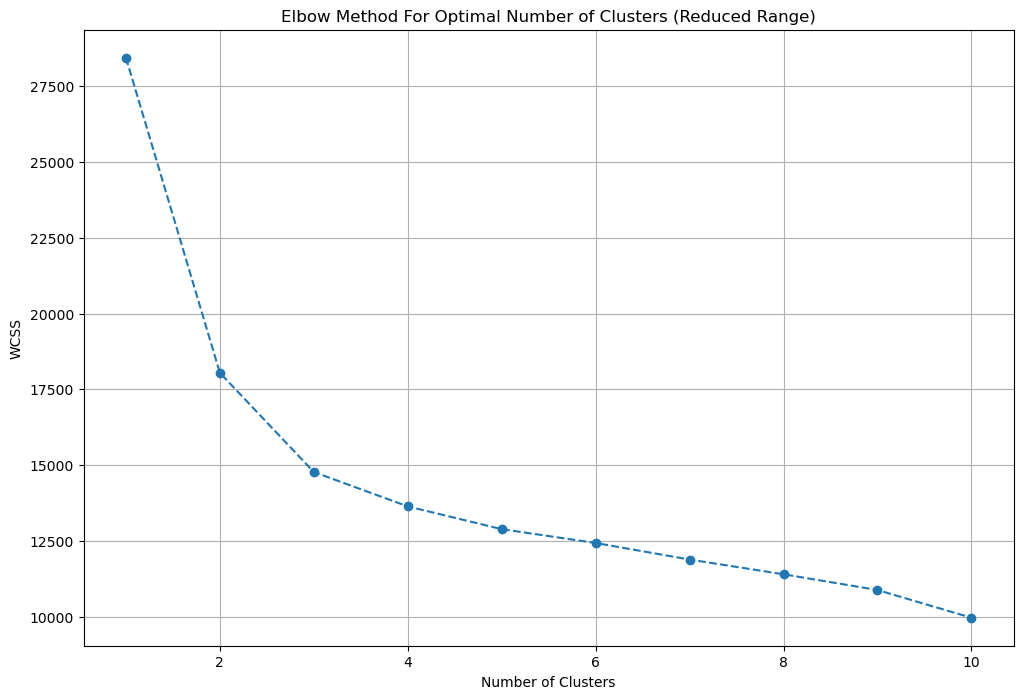

In [43]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [44]:
n_clusters = 3

# Fit the KMeans model
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(scaled_data)

# Predict the cluster assignments for each row
cluster_assignments = kmeans.predict(scaled_data)

In [45]:
df = df.iloc[:,:-18]

In [46]:
df['furnishing_type'] = cluster_assignments

In [47]:
df.sample(20)[['furnishing','furnishing_type']]
# 0 -> unfurnished
# 1 -> semifurnished
# 2 -> furnished

,furnishing,furnishing_type
107,NaN,1
1043,NaN,1
408,NaN,1
748,NaN,1
413,"['1 Fan', '1 Exhaust Fan', '2 Light', '1 Curtains', '1 Modular Kitchen', '1 Chimney', 'No AC', 'No Bed', 'No Dining Table', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",0
766,NaN,1
1446,NaN,1
43,NaN,1
907,NaN,1
1543,"['1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",1


# 5.features

In [48]:
df[['society','features']].sample(5)

,society,features
732,comfort heights,"['Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking', 'Waste Disposal', 'Rain Water Harvesting']"
946,hoshangabad,"['Private Garden / Terrace', 'Water Storage', 'Natural Light', 'Airy Rooms', 'Spacious Interiors']"
452,sheetal dham,"['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Lift(s)', 'Maintenance Staff', 'Swimming Pool', 'Water Storage', 'Park', 'Visitor Parking', 'Fitness Centre / GYM', 'Club house / Community Center']"
283,danish nagar,NaN
647,sai baba apartment,"['Water Storage', 'Park']"


In [49]:
df['features'].isnull().sum()

565

In [50]:
df['society'].value_counts().shape

(838,)

In [51]:
df['society'].value_counts()

society
awadhpuri                                           20
globus coral woods                                  19
sarvadharm colony                                   15
ibd hallmark citii                                  15
fortune soumya heritage                             14
nirupam royal palms                                 13
kolar road                                          13
danish hills view                                   12
agrawal sagar golden palm                           12
agrawal sagar lakeview homes                        11
ayodhya bypass                                      11
saket nagar                                         10
signature 360                                       10
fortune kasturi                                     10
lakhumal nikhil nestles                             10
hoshangabad road                                     9
ayodhya nagar                                        9
bawadia kalan                                        8
sa

In [52]:
df[df['society']=='fortune soumya heritage']['features']

165                                         ['Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Swimming Pool', 'Maintenance Staff', 'Park', 'Security Personnel', 'Fitness Centre / GYM', 'Club house / Community Center', 'Rain Water Harvesting', 'Water softening plant']
209     ['Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Fitness Centre / GYM', 'Rain Water Harvesting', 'Club house / Community Center']
417                                                                                                                                                                                                                                                                                                      NaN
432                                                                  ['Power Back-up', 'Feng Shui

In [53]:
# fill features values
df['features'] = ( df.groupby('society')['features'] .transform(lambda x: x.ffill().bfill()) )

In [54]:
import ast
from sklearn.preprocessing import MultiLabelBinarizer

In [55]:

# Convert the string representation of lists in the 'features' column to actual lists
df['features_list'] = df['features'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else [])

# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['features_list'])


# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)


In [56]:
features_binary_df.sample(5)

,Airy Rooms,Bank Attached Property,Centrally Air Conditioned,Club house / Community Center,False Ceiling Lighting,Feng Shui / Vaastu Compliant,Fitness Centre / GYM,High Ceiling Height,Intercom Facility,Internet/wi-fi connectivity,Lift(s),Low Density Society,Maintenance Staff,Natural Light,No open drainage around,Park,Piped-gas,Power Back-up,Private Garden / Terrace,Rain Water Harvesting,Recently Renovated,Security / Fire Alarm,Security Personnel,Separate entry for servant room,Shopping Centre,Spacious Interiors,Swimming Pool,Visitor Parking,Waste Disposal,Water Storage,Water purifier,Water softening plant
752,1,0,0,1,0,0,1,0,1,0,1,0,1,1,0,1,0,0,0,1,0,1,0,0,0,0,1,1,1,0,0,0
824,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
574,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,1,0,0
479,1,1,0,1,0,0,1,0,0,0,1,0,1,1,0,1,1,1,0,1,0,0,1,0,0,0,1,0,1,1,1,0
654,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0


In [57]:
features_binary_df.shape

(1580, 32)

In [58]:
features_binary_df.columns

Index(['Airy Rooms', 'Bank Attached Property', 'Centrally Air Conditioned',
       'Club house / Community Center', 'False Ceiling Lighting',
       'Feng Shui / Vaastu Compliant', 'Fitness Centre / GYM',
       'High Ceiling Height', 'Intercom Facility',
       'Internet/wi-fi connectivity', 'Lift(s)', 'Low Density Society',
       'Maintenance Staff', 'Natural Light', 'No open drainage around', 'Park',
       'Piped-gas', 'Power Back-up', 'Private Garden / Terrace',
       'Rain Water Harvesting', 'Recently Renovated', 'Security / Fire Alarm',
       'Security Personnel', 'Separate entry for servant room',
       'Shopping Centre', 'Spacious Interiors', 'Swimming Pool',
       'Visitor Parking', 'Waste Disposal', 'Water Storage', 'Water purifier',
       'Water softening plant'],
      dtype='object')

# apply clustering

In [59]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(features_binary_df)
    wcss_reduced.append(kmeans.inertia_)

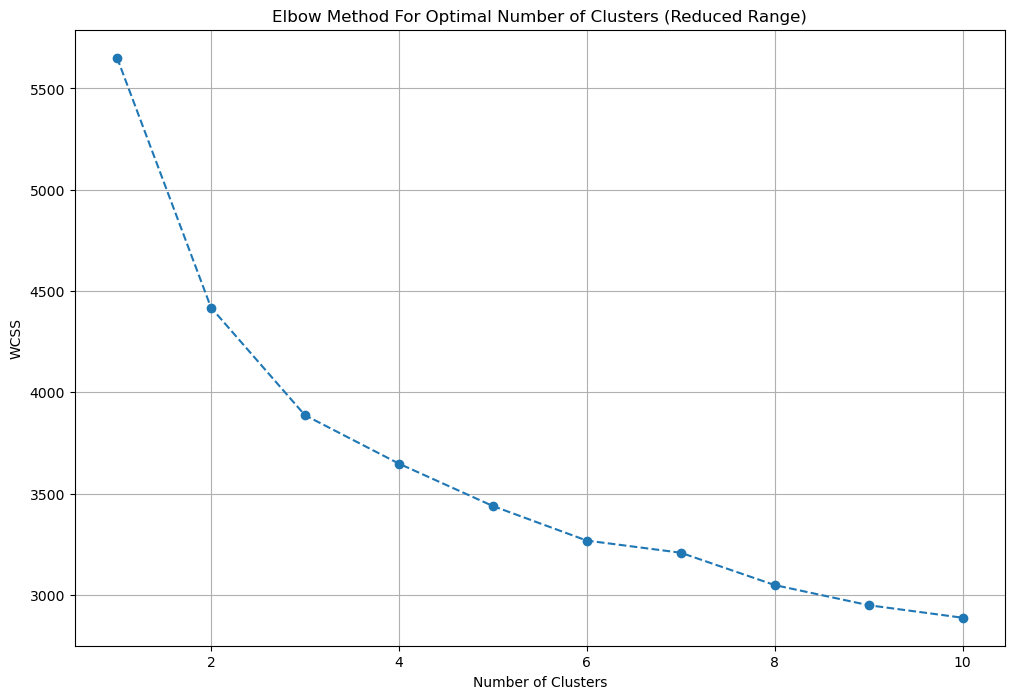

In [60]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [61]:
luxury_weights = {

    # ULTRA LUXURY (9–10)
    'Private Garden / Terrace': 10,
    'Low Density Society': 10,
    'High Ceiling Height': 9,
    'Spacious Interiors': 9,

    # HIGH LUXURY (7–8)
    'Swimming Pool': 8,
    'Club house / Community Center': 8,
    'Fitness Centre / GYM': 7,
    'Centrally Air Conditioned': 7,
    'Separate entry for servant room': 7,
    'Recently Renovated': 7,
    'Shopping Centre': 7,

    # PREMIUM (5–6)
    'Lift(s)': 6,
    'Security Personnel': 6,
    'Security / Fire Alarm': 6,
    'Power Back-up': 6,
    'Visitor Parking': 5,
    'False Ceiling Lighting': 5,
    'Intercom Facility': 5,
    'Internet/wi-fi connectivity': 5,
    'Airy Rooms': 5,
    'Natural Light': 5,

    # COMFORT (3–4)
    'Maintenance Staff': 4,
    'Park': 4,
    'Piped-gas': 3,
    'Water purifier': 3,
    'Water softening plant': 3,
    'Rain Water Harvesting': 3,
    'Waste Disposal': 3,
    'Water Storage': 3,

    # BASIC / HYGIENE (1–2)
    'Feng Shui / Vaastu Compliant': 2,
    'No open drainage around': 1,
    'Bank Attached Property': 1
}
luxury_score = features_binary_df[list(luxury_weights.keys())].multiply(list(luxury_weights.values())).sum(axis=1)


In [62]:
df['luxury_score'] = luxury_score

In [63]:
df.head()

,pname,society,colony,property_type,price_outer,price_per_sqft,possesion,Area,Total Floors,Facing,Property Age,furnishing,features,Overlooking,bedrooms,bathrooms,balconies,additional_room,area,super_built_up_area,built_up_area,carpet_area,plot_area,study room,servant room,store room,pooja room,others,view floor plan,furnishing_type,features_list,luxury_score
0,"7 Bedroom House for sale in Jhagariya Khurd, Bhopal",sage suncity,bhopal,House,105.0,3750,Ready To Move,Built Up area: 2800(260.13 sq.m.) sq.ft.,1.0,NaN,None,NaN,"['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'Water Storage', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Club house / Community Center']",NaN,7,5,0,not available,2800.00,NaN,2800.0,NaN,NaN,0,0,0,0,0,0,1,"[Feng Shui / Vaastu Compliant, Private Garden / Terrace, High Ceiling Height, Water Storage, Park, Security Personnel, Natural Light, Airy Rooms, Spacious Interiors, Low Density Society, Club house / Community Center]",71
1,"3 BHK Flat in Kolar Road, Bhopal",danish hills view,kolar road,Flat,85.0,6508,Ready To Move,Carpet area: 1306(121.33 sq.m.) sq.ft.,2.0,North,New Property,NaN,"['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']",Park/Garden,3,3,1,pooja room with view floor plan,1306.08,NaN,NaN,1306.0,NaN,0,0,0,1,0,1,1,"[Feng Shui / Vaastu Compliant, Security / Fire Alarm, Intercom Facility, Lift(s), Maintenance Staff, Water Storage, Park, Visitor Parking]",35
2,"2 BHK Flat in Katara Hills, Bhopal",narmada prem kesar,katara hills,Flat,25.0,2173,Ready To Move,Super Built up area 1150(106.84 sq.m.)Carpet area: 850 sq.ft. (78.97 sq.m.) sq.ft.,3.0,West,New Property,NaN,"['Feng Shui / Vaastu Compliant', 'Lift(s)', 'Maintenance Staff', 'Water Storage']","Park/Garden,Main Road",2,2,3,not available,1150.48,1150.0,NaN,850.0,NaN,0,0,0,0,0,0,1,"[Feng Shui / Vaastu Compliant, Lift(s), Maintenance Staff, Water Storage]",15
3,"8 Bedroom House for sale in Gurunanak Pura, Bhopal",gurunanak pura independent house,aishbagh,House,65.0,5909,Ready To Move,Plot area 1100(102.19 sq.m.)Built Up area: 2400 sq.ft. (222.97 sq.m.)Carpet area: 2200 sq.ft. (204.39 sq.m.) sq.ft.,2.0,West,Old Property,"['1 Water Purifier', '12 Fan', '1 Geyser', '22 Light', '2 AC', '1 Chimney', '8 Curtains', '1 Modular Kitchen', '1 TV', '3 Wardrobe', '1 Sofa', 'No Bed', 'No Dining Table', 'No Exhaust Fan', 'No Microwave', 'No Fridge', 'No Stove', 'No Washing Machine']","['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Water Storage', 'Waste Disposal']",Main Road,8,5,1,pooja room,1100.02,NaN,2400.0,2200.0,1100.0,0,0,0,1,0,0,0,"[Feng Shui / Vaastu Compliant, Private Garden / Terrace, Water Storage, Waste Disposal]",18
4,"6 Bedroom House for sale in Chuna Bhatti, Bhopal",chuna bhatti,chuna bhatti,House,650.0,16250,Ready To Move,Plot area 4000(371.61 sq.m.) sq.ft.,3.0,NaN,New Property,"['1 Water Purifier', '1 Fan', '1 Exhaust Fan', '1 Dining Table', '1 Stove', '1 Light', '1 Modular Kitchen', '1 Chimney', '1 AC', '1 Curtains', '1 Sofa', '1 Microwave', 'No Bed', 'No Geyser', 'No Fridge', 'No TV', 'No Wardrobe', 'No Washing Machine']",['Private Garden / Terrace'],NaN,6,6,2,"pooja room,study room,servant room,store room",4000.00,NaN,NaN,NaN,4000.0,1,1,1,1,0,0,2,[Private Garden / Terrace],10


In [64]:
df.groupby('furnishing_type')['luxury_score'].mean()

furnishing_type
0    36.474227
1    21.506193
2    40.743590
Name: luxury_score, dtype: float64

In [65]:
df.columns

Index(['pname', 'society', 'colony', 'property_type', 'price_outer',
       'price_per_sqft', 'possesion', 'Area', 'Total Floors', 'Facing',
       'Property Age', 'furnishing', 'features', 'Overlooking', 'bedrooms',
       'bathrooms', 'balconies', 'additional_room', 'area',
       'super_built_up_area', 'built_up_area', 'carpet_area', 'plot_area',
       'study room', 'servant room', 'store room', 'pooja room', 'others',
       'view floor plan', 'furnishing_type', 'features_list', 'luxury_score'],
      dtype='object')

In [66]:
df.sample(5)

,pname,society,colony,property_type,price_outer,price_per_sqft,possesion,Area,Total Floors,Facing,Property Age,furnishing,features,Overlooking,bedrooms,bathrooms,balconies,additional_room,area,super_built_up_area,built_up_area,carpet_area,plot_area,study room,servant room,store room,pooja room,others,view floor plan,furnishing_type,features_list,luxury_score
374,"3 BHK Flat in Katara Hills, Bhopal",agrawal sagar golden palm,katara hills,Flat,34.0,2142,Ready To Move,Super Built up area 1400(130.06 sq.m.) sq.ft.,6.0,NaN,Moderate Property,NaN,"['Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Fitness Centre / GYM', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']","Pool,Park/Garden,Club",3,2,3,not available,1587.30,1400.0,NaN,NaN,NaN,0,0,0,0,0,0,1,"[Power Back-up, Feng Shui / Vaastu Compliant, Intercom Facility, Lift(s), Maintenance Staff, Swimming Pool, Park, Security Personnel, Internet/wi-fi connectivity, Fitness Centre / GYM, Rain Water Harvesting, Club house / Community Center, Water softening plant]",67
1463,"1 BHK Flat in Khajuri Kalan , Bhopal",draupadi shivlok heights,khajuri kalan,Flat,10.0,2857,Ready To Move,Super Built up area 350(32.52 sq.m.) sq.ft.,1.0,NaN,Moderate Property,NaN,NaN,NaN,1,1,1,not available,350.02,350.0,NaN,NaN,NaN,0,0,0,0,0,0,1,[],0
649,"4 Bedroom House for sale in Trilanga, Bhopal",trilanga,shahpura,House,120.0,12000,Ready To Move,Plot area 1000(92.9 sq.m.) sq.ft.,2.0,West,Moderate Property,"['6 Fan', '1 Exhaust Fan', '1 Dining Table', '2 Geyser', '4 Light', '1 Chimney', '1 Modular Kitchen', '2 AC', '1 Curtains', '9 Wardrobe', '4 Bed', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Water Storage', 'Visitor Parking']",NaN,4,4,2,pooja room,1000.00,NaN,NaN,NaN,1000.0,0,0,0,1,0,0,0,"[Water Storage, Visitor Parking]",8
283,"3 Bedroom House for sale in Danish Nagar, Bhopal",danish nagar,bagmugaliya,House,138.0,11500,Ready To Move,Plot area 1200(111.48 sq.m.) sq.ft.,2.0,South,Old Property,"['2 Bed', '2 Wardrobe', '4 Fan', '3 Light', 'No AC', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Water Storage', 'Park']",Main Road,3,3,2,not available,1200.00,NaN,NaN,NaN,1200.0,0,0,0,0,0,0,1,"[Feng Shui / Vaastu Compliant, Private Garden / Terrace, Water Storage, Park]",19
1314,"3 BHK Flat in Salaiya, Bhopal",shiva whispering woods,salaiya,Flat,40.0,4166,Ready To Move,Built Up area: 1200(111.48 sq.m.)Carpet area: 960 sq.ft. (89.19 sq.m.) sq.ft.,3.0,NaN,New Property,"['2 Fan', '1 Exhaust Fan', '5 Light', '1 Modular Kitchen', '1 Chimney', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",['Maintenance Staff'],NaN,3,2,2,not available,960.15,NaN,1200.0,960.0,NaN,0,0,0,0,0,0,0,[Maintenance Staff],4


In [67]:
df.shape

(1580, 32)

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1580 entries, 0 to 1579
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   pname                1580 non-null   object 
 1   society              1576 non-null   object 
 2   colony               1580 non-null   object 
 3   property_type        1580 non-null   object 
 4   price_outer          1580 non-null   float64
 5   price_per_sqft       1580 non-null   int64  
 6   possesion            1580 non-null   object 
 7   Area                 1580 non-null   object 
 8   Total Floors         1546 non-null   float64
 9   Facing               876 non-null    object 
 10  Property Age         1443 non-null   object 
 11  furnishing           673 non-null    object 
 12  features             1271 non-null   object 
 13  Overlooking          792 non-null    object 
 14  bedrooms             1580 non-null   int64  
 15  bathrooms            1580 non-null   i

# Overlooking

In [69]:
df['Overlooking'].isnull().sum()

788

In [70]:
# fill features values
df['Overlooking'] = ( df.groupby('society')['Overlooking'] .transform(lambda x: x.ffill().bfill()) )

In [71]:
df['Overlooking'].isnull().sum()

435

In [72]:
df['Overlooking'].value_counts()

Overlooking
Park/Garden                                          248
Main Road                                            211
Park/Garden,Main Road                                149
Others                                                48
Park/Garden,Club,Main Road                            43
Pool,Park/Garden,Club,Main Road                       41
Park/Garden,Main Road,Others                          34
Park/Garden,Main Road,Club                            31
Park/Garden,Club                                      31
Pool,Park/Garden,Club                                 22
Main Road,Park/Garden                                 19
Main Road,Others                                      19
Pool,Park/Garden                                      12
Pool,Others,Park/Garden,Club,Main Road                12
Park/Garden,Others,Main Road                          11
Park/Garden,Club,Main Road,Others                     10
Pool,Park/Garden,Club,Main Road,Others                10
Club,Park/Garden   

In [73]:
priority_order = [
    'Park/Garden',
    'Main Road',
    'Club',
    'Pool',
    'Others',
    'Sea facing'
]

In [74]:
def reorder_overlooking(val, priority):
    if pd.isna(val) or val.strip() == '':
        return val
    
    items = [v.strip() for v in val.split(',')]
    ordered_items = [p for p in priority if p in items]
    
    return ','.join(ordered_items)

In [75]:
overlooking_temp = df['Overlooking'].apply(
    lambda x: reorder_overlooking(x, priority_order)
)

In [76]:
overlooking_temp.head()

0    Park/Garden,Main Road
1              Park/Garden
2    Park/Garden,Main Road
3                Main Road
4                Main Road
Name: Overlooking, dtype: object

In [77]:
overlooking_dummies = (
    overlooking_temp
    .str.get_dummies(sep=','))

overlooking_dummies

,Club,Main Road,Others,Park/Garden,Pool,Sea facing
0,0,1,0,1,0,0
1,0,0,0,1,0,0
2,0,1,0,1,0,0
3,0,1,0,0,0,0
4,0,1,0,0,0,0
5,0,0,0,0,0,0
6,0,0,0,0,0,0
7,0,0,0,1,0,0
8,0,1,0,0,0,0
9,0,1,0,1,0,0


In [78]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(overlooking_dummies)

In [79]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

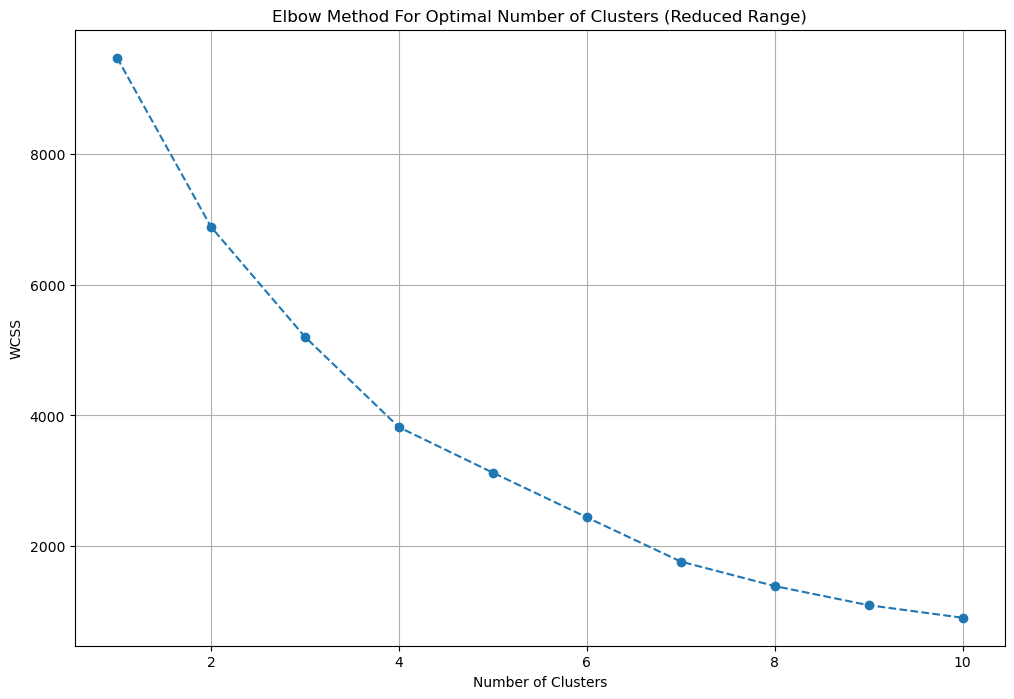

In [80]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [81]:
n_clusters = 4

# Fit the KMeans model
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(scaled_data)

# Predict the cluster assignments for each row
cluster_assignments = kmeans.predict(scaled_data)

In [82]:
temp = overlooking_temp.reset_index()
temp['category'] = cluster_assignments
temp

,index,Overlooking,category
0,0,"Park/Garden,Main Road",3
1,1,Park/Garden,3
2,2,"Park/Garden,Main Road",3
3,3,Main Road,0
4,4,Main Road,0
5,5,NaN,0
6,6,NaN,0
7,7,Park/Garden,3
8,8,Main Road,0
9,9,"Park/Garden,Main Road",3


In [83]:
temp.groupby(['Overlooking','category']).count().sort_values(by='index',ascending=False)

,,index
Overlooking,category,
Park/Garden,3,248
Main Road,0,211
"Park/Garden,Main Road",3,168
"Park/Garden,Main Road,Club",1,84
"Park/Garden,Main Road,Club,Pool",1,61
"Park/Garden,Main Road,Others",3,57
"Park/Garden,Main Road,Club,Pool,Others",1,50
Others,0,48
"Park/Garden,Club",1,39


In [84]:
category_map = {
    3: 'Green View Homes',
    1: 'Amenity Facing Homes',
    0: 'Road Facing Homes',
    2: 'Premium Scenic Homes'
}

df['Overlooking_Categories'] = temp['category'].map(category_map)


In [85]:
df.head()

,pname,society,colony,property_type,price_outer,price_per_sqft,possesion,Area,Total Floors,Facing,Property Age,furnishing,features,Overlooking,bedrooms,bathrooms,balconies,additional_room,area,super_built_up_area,built_up_area,carpet_area,plot_area,study room,servant room,store room,pooja room,others,view floor plan,furnishing_type,features_list,luxury_score,Overlooking_Categories
0,"7 Bedroom House for sale in Jhagariya Khurd, Bhopal",sage suncity,bhopal,House,105.0,3750,Ready To Move,Built Up area: 2800(260.13 sq.m.) sq.ft.,1.0,NaN,None,NaN,"['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'Water Storage', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Club house / Community Center']","Park/Garden,Main Road",7,5,0,not available,2800.00,NaN,2800.0,NaN,NaN,0,0,0,0,0,0,1,"[Feng Shui / Vaastu Compliant, Private Garden / Terrace, High Ceiling Height, Water Storage, Park, Security Personnel, Natural Light, Airy Rooms, Spacious Interiors, Low Density Society, Club house / Community Center]",71,Green View Homes
1,"3 BHK Flat in Kolar Road, Bhopal",danish hills view,kolar road,Flat,85.0,6508,Ready To Move,Carpet area: 1306(121.33 sq.m.) sq.ft.,2.0,North,New Property,NaN,"['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']",Park/Garden,3,3,1,pooja room with view floor plan,1306.08,NaN,NaN,1306.0,NaN,0,0,0,1,0,1,1,"[Feng Shui / Vaastu Compliant, Security / Fire Alarm, Intercom Facility, Lift(s), Maintenance Staff, Water Storage, Park, Visitor Parking]",35,Green View Homes
2,"2 BHK Flat in Katara Hills, Bhopal",narmada prem kesar,katara hills,Flat,25.0,2173,Ready To Move,Super Built up area 1150(106.84 sq.m.)Carpet area: 850 sq.ft. (78.97 sq.m.) sq.ft.,3.0,West,New Property,NaN,"['Feng Shui / Vaastu Compliant', 'Lift(s)', 'Maintenance Staff', 'Water Storage']","Park/Garden,Main Road",2,2,3,not available,1150.48,1150.0,NaN,850.0,NaN,0,0,0,0,0,0,1,"[Feng Shui / Vaastu Compliant, Lift(s), Maintenance Staff, Water Storage]",15,Green View Homes
3,"8 Bedroom House for sale in Gurunanak Pura, Bhopal",gurunanak pura independent house,aishbagh,House,65.0,5909,Ready To Move,Plot area 1100(102.19 sq.m.)Built Up area: 2400 sq.ft. (222.97 sq.m.)Carpet area: 2200 sq.ft. (204.39 sq.m.) sq.ft.,2.0,West,Old Property,"['1 Water Purifier', '12 Fan', '1 Geyser', '22 Light', '2 AC', '1 Chimney', '8 Curtains', '1 Modular Kitchen', '1 TV', '3 Wardrobe', '1 Sofa', 'No Bed', 'No Dining Table', 'No Exhaust Fan', 'No Microwave', 'No Fridge', 'No Stove', 'No Washing Machine']","['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Water Storage', 'Waste Disposal']",Main Road,8,5,1,pooja room,1100.02,NaN,2400.0,2200.0,1100.0,0,0,0,1,0,0,0,"[Feng Shui / Vaastu Compliant, Private Garden / Terrace, Water Storage, Waste Disposal]",18,Road Facing Homes
4,"6 Bedroom House for sale in Chuna Bhatti, Bhopal",chuna bhatti,chuna bhatti,House,650.0,16250,Ready To Move,Plot area 4000(371.61 sq.m.) sq.ft.,3.0,NaN,New Property,"['1 Water Purifier', '1 Fan', '1 Exhaust Fan', '1 Dining Table', '1 Stove', '1 Light', '1 Modular Kitchen', '1 Chimney', '1 AC', '1 Curtains', '1 Sofa', '1 Microwave', 'No Bed', 'No Geyser', 'No Fridge', 'No TV', 'No Wardrobe', 'No Washing Machine']",['Private Garden / Terrace'],Main Road,6,6,2,"pooja room,study room,servant room,store room",4000.00,NaN,NaN,NaN,4000.0,1,1,1,1,0,0,2,[Private Garden / Terrace],10,Road Facing Homes


In [86]:
# df.drop(columns=['Overlooking','possesion','pname'],inplace=True)
# cols to drop -> nearbyLocations,furnishDetails, features,features_list, additionalRoom
# df.drop(columns=['features_list','additional_room','features','furnishing','Property Age','Area'],inplace=True)

In [87]:
df.head(1)

,pname,society,colony,property_type,price_outer,price_per_sqft,possesion,Area,Total Floors,Facing,Property Age,furnishing,features,Overlooking,bedrooms,bathrooms,balconies,additional_room,area,super_built_up_area,built_up_area,carpet_area,plot_area,study room,servant room,store room,pooja room,others,view floor plan,furnishing_type,features_list,luxury_score,Overlooking_Categories
0,"7 Bedroom House for sale in Jhagariya Khurd, Bhopal",sage suncity,bhopal,House,105.0,3750,Ready To Move,Built Up area: 2800(260.13 sq.m.) sq.ft.,1.0,NaN,None,NaN,"['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'Water Storage', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Club house / Community Center']","Park/Garden,Main Road",7,5,0,not available,2800.0,NaN,2800.0,NaN,NaN,0,0,0,0,0,0,1,"[Feng Shui / Vaastu Compliant, Private Garden / Terrace, High Ceiling Height, Water Storage, Park, Security Personnel, Natural Light, Airy Rooms, Spacious Interiors, Low Density Society, Club house / Community Center]",71,Green View Homes


In [88]:
df.drop(columns=['Overlooking','possesion','pname','features_list','additional_room','features','furnishing','Area'],inplace=True)

In [89]:
df.head()

,society,colony,property_type,price_outer,price_per_sqft,Total Floors,Facing,Property Age,bedrooms,bathrooms,balconies,area,super_built_up_area,built_up_area,carpet_area,plot_area,study room,servant room,store room,pooja room,others,view floor plan,furnishing_type,luxury_score,Overlooking_Categories
0,sage suncity,bhopal,House,105.0,3750,1.0,NaN,None,7,5,0,2800.00,NaN,2800.0,NaN,NaN,0,0,0,0,0,0,1,71,Green View Homes
1,danish hills view,kolar road,Flat,85.0,6508,2.0,North,New Property,3,3,1,1306.08,NaN,NaN,1306.0,NaN,0,0,0,1,0,1,1,35,Green View Homes
2,narmada prem kesar,katara hills,Flat,25.0,2173,3.0,West,New Property,2,2,3,1150.48,1150.0,NaN,850.0,NaN,0,0,0,0,0,0,1,15,Green View Homes
3,gurunanak pura independent house,aishbagh,House,65.0,5909,2.0,West,Old Property,8,5,1,1100.02,NaN,2400.0,2200.0,1100.0,0,0,0,1,0,0,0,18,Road Facing Homes
4,chuna bhatti,chuna bhatti,House,650.0,16250,3.0,NaN,New Property,6,6,2,4000.00,NaN,NaN,NaN,4000.0,1,1,1,1,0,0,2,10,Road Facing Homes


In [90]:
# df[(df['built_up_area']>df['effective_area_sqft'])|(df['carpet_area']>df['effective_area_sqft'])]

In [91]:
df.to_csv('BPL_feature_engineered_v2.csv',index=False)
df.to_excel('BPL_feature_engineered_v2.xlsx',index=False)